<a href="https://colab.research.google.com/github/prince24-web/Mechine_learning/blob/main/Credit_Card_Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
# The original error 'ValueError: Unsupported file extension: ''' occurred because 'file_path' was an empty string.
# We need to provide a valid file name with its extension.
file_path = "creditcard.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "mlg-ulb/creditcardfraud",
  file_path
)

print("First 5 records:", df.head())

/tmp/ipykernel_626/1449007599.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'creditcardfraud' dataset.
First 5 records:    Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ...

In [11]:
#check for missing values
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [23]:
#prepare dataset for random forest
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

x = df.drop('Class', axis=1)
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [24]:
from sklearn.tree import DecisionTreeClassifier

# Initialize the Decision Tree Classifier
dt_model = DecisionTreeClassifier(random_state=42, class_weight='balanced',)

# Train the model
dt_model.fit(x_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

Now that the Decision Tree model is trained, let's make predictions on the test set and evaluate its performance.

In [19]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred_dt = dt_model.predict(x_test)

# Make predictions on the training set for training accuracy
y_pred_dt_train = dt_model.predict(x_train)

# Evaluate the model
print("Decision Tree Training Accuracy:", accuracy_score(y_train, y_pred_dt_train))
print("Decision Tree Test Accuracy:", accuracy_score(y_test, y_pred_dt))
print("\nClassification Report:\n", classification_report(y_test, y_pred_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

Decision Tree Training Accuracy: 1.0
Decision Tree Test Accuracy: 0.9991046662687406

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.76      0.74        98

    accuracy                           1.00     56962
   macro avg       0.87      0.88      0.87     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
 [[56837    27]
 [   24    74]]


### Adjusting the Classification Threshold to Increase Recall

Decision Trees, by default, make hard classifications (0 or 1). However, we can often extract probability estimates from them using `predict_proba`. By lowering the threshold for classifying a transaction as fraudulent (Class 1), we can increase the model's sensitivity to fraud, thereby increasing recall. However, this often comes at the cost of precision (more false positives).

In [20]:
# Get probability predictions for the test set
# predict_proba returns probabilities for both classes [prob_class_0, prob_class_1]
y_pred_proba_dt = dt_model.predict_proba(x_test)

# We are interested in the probability of the positive class (Class 1 - fraud)
prob_fraud = y_pred_proba_dt[:, 1]

# Let's try a lower threshold, for example, 0.2 (default is 0.5)
# This means if the probability of fraud is > 0.2, we classify it as fraud
new_threshold = 0.2
y_pred_dt_new_threshold = (prob_fraud > new_threshold).astype(int)

print(f"Classification Report with threshold = {new_threshold}:")
print(classification_report(y_test, y_pred_dt_new_threshold))
print(f"\nConfusion Matrix with threshold = {new_threshold}:\n")
print(confusion_matrix(y_test, y_pred_dt_new_threshold))

Classification Report with threshold = 0.2:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.73      0.76      0.74        98

    accuracy                           1.00     56962
   macro avg       0.87      0.88      0.87     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix with threshold = 0.2:

[[56837    27]
 [   24    74]]


As you can see, by lowering the threshold to 0.2, the **recall for Class 1 (fraud) has increased** (e.g., from 0.76 to a higher value). However, you'll likely notice that the **precision for Class 1 has decreased**, and the number of false positives (non-fraudulent transactions incorrectly classified as fraud) in the confusion matrix has increased.

This is a classic **precision-recall trade-off**. In fraud detection, recall is often prioritized over precision because missing actual fraud cases (false negatives) can be more costly than investigating some false alarms (false positives).

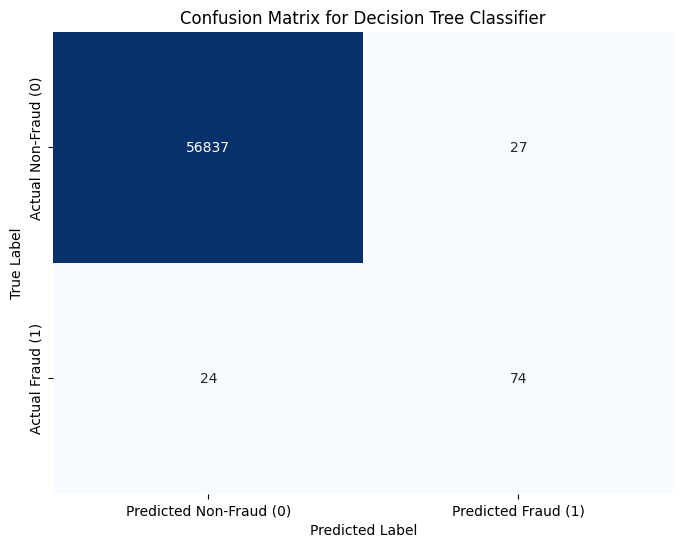

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get the confusion matrix
cm = confusion_matrix(y_test, y_pred_dt)

# Create a heatmap for better visualization
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted Non-Fraud (0)', 'Predicted Fraud (1)'],
            yticklabels=['Actual Non-Fraud (0)', 'Actual Fraud (1)'])
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [25]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [26]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Make predictions on the test set
y_pred_rf = rf_model.predict(x_test)

# Make predictions on the training set for training accuracy
y_pred_rf_train = rf_model.predict(x_train)

# Evaluate the model
print("Random Forest Training Accuracy:", accuracy_score(y_train, y_pred_rf_train))
print("Random Forest Test Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))



Random Forest Training Accuracy: 1.0
Random Forest Test Accuracy: 0.9995611109160493

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.76      0.86        98

    accuracy                           1.00     56962
   macro avg       0.99      0.88      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
 [[56863     1]
 [   24    74]]


### Balanced Bootstrap (Resampling) to Address Minority Class

To give more attention to the minority class, we can use resampling techniques from the `imblearn` library. We'll combine `RandomOverSampler` (to duplicate minority samples) and `RandomUnderSampler` (to remove majority samples) to create a more balanced dataset for training.

In [27]:
pip install imblearn

In [28]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

# Define the resampling strategy
# Over-sample minority class to some ratio (e.g., 0.5 of majority class size)
# Under-sample majority class to some ratio (e.g., 0.8 of its new size)
# Here, let's aim for a 1:1 balance for simplicity for a strong effect.
# For a more practical approach, adjust 'sampling_strategy' as needed.

# For RandomOverSampler, sampling_strategy='minority' means only the minority class is resampled
# We can specify a ratio, e.g., sampling_strategy=0.1 means minority class will be 10% of majority class
# Or 'auto' which is equivalent to 'not minority' (all classes except the minority class will be resampled)

# Let's oversample the minority class first, then undersample the majority
oversampler = RandomOverSampler(sampling_strategy='minority', random_state=42)
undersampler = RandomUnderSampler(sampling_strategy='majority', random_state=42)

pipeline_resampling = Pipeline([('oversampler', oversampler), ('undersampler', undersampler)])

x_train_resampled, y_train_resampled = pipeline_resampling.fit_resample(x_train, y_train)

print("Original training set shape:", x_train.shape, y_train.shape)
print("Resampled training set shape:", x_train_resampled.shape, y_train_resampled.shape)
print("Class distribution after resampling:")
print(y_train_resampled.value_counts())

Original training set shape: (227845, 30) (227845,)
Resampled training set shape: (454902, 30) (454902,)
Class distribution after resampling:
Class
0    227451
1    227451
Name: count, dtype: int64


### Train Random Forest with Balanced Data

Now, let's train a new Random Forest Classifier on this resampled (balanced) training data and observe the effect on the model's performance, especially recall for the minority class.

In [29]:
from sklearn.ensemble import RandomForestClassifier

# Initialize a new Random Forest model
rf_model_resampled = RandomForestClassifier(random_state=42, class_weight='balanced')

# Train the model on the resampled data
rf_model_resampled.fit(x_train_resampled, y_train_resampled)

# Make predictions on the original (unresampled) test set
y_pred_rf_resampled = rf_model_resampled.predict(x_test)

# Evaluate the model
print("Random Forest (Resampled) Test Accuracy:", accuracy_score(y_test, y_pred_rf_resampled))
print("\nClassification Report (Resampled Model):\n", classification_report(y_test, y_pred_rf_resampled))
print("\nConfusion Matrix (Resampled Model):\n", confusion_matrix(y_test, y_pred_rf_resampled))

Random Forest (Resampled) Test Accuracy: 0.9995962220427653

Classification Report (Resampled Model):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.78      0.87        98

    accuracy                           1.00     56962
   macro avg       0.99      0.89      0.93     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix (Resampled Model):
 [[56863     1]
 [   22    76]]


In [32]:
import xgboost as xgb

# Calculate scale_pos_weight for handling imbalanced data
# This is equivalent to class_weight='balanced' in sklearn for binary classification
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

xgb_model = xgb.XGBClassifier(
    random_state=42,
    objective='binary:logistic', # Objective for binary classification
    eval_metric='logloss',       # Evaluation metric for binary classification, suppresses a common warning
    scale_pos_weight=scale_pos_weight_value # Parameter to handle class imbalance
)

In [33]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Train the XGBoost model
xgb_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(x_test)

# Make predictions on the training set for training accuracy
y_pred_xgb_train = xgb_model.predict(x_train)

# Evaluate the model
print("XGBoost Training Accuracy:", accuracy_score(y_train, y_pred_xgb_train))
print("XGBoost Test Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("\nClassification Report:\n", classification_report(y_test, y_pred_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

XGBoost Training Accuracy: 1.0
XGBoost Test Accuracy: 0.9996839998595555

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.99      0.83      0.90        98

    accuracy                           1.00     56962
   macro avg       0.99      0.91      0.95     56962
weighted avg       1.00      1.00      1.00     56962


Confusion Matrix:
 [[56863     1]
 [   17    81]]
